# 2. Feature Engineering & Model Development

This notebook covers:
- Feature preprocessing (scaling and encoding)
- Model development (Logistic Regression & XGBoost)
- Hyperparameter tuning
- Cross-validation and comprehensive evaluation

## 2.1 Import Required Libraries

In [103]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2, f_classif, mutual_info_classif
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestClassifier

# Model selection and evaluation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold, KFold

# Models
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Utilities
import warnings
import joblib
import os
from datetime import datetime
import json

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2.2 Load Data

In [104]:
# Load cleaned data from previous notebook
df = pd.read_csv('data/cleaned_data.csv')
print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")
display(df.head())
display(df.info())

Data loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


None

## 2.3 Feature Engineering

### 2.3.1 Separate Features and Target

In [105]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance ratio: {y.value_counts().max() / y.value_counts().min():.2f}:1")

Features shape: (303, 13)
Target shape: (303,)

Target distribution:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Class balance ratio: 12.62:1


In [106]:
### 2.3.2 Handle Categorical Features

In [107]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}...")

# Encode categorical features if any
if len(categorical_cols) > 0:
    print(f"\nEncoding {len(categorical_cols)} categorical features...")
    le = LabelEncoder()
    for col in categorical_cols:
        X[col] = le.fit_transform(X[col].astype(str))
    print("Encoding completed!")
else:
    print("\nNo categorical features to encode - all features are numerical")

Categorical columns (0): []
Numerical columns (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']...

No categorical features to encode - all features are numerical


### 2.3.3 Train-Test Split

In [108]:
# Split data into train and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data split completed!")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain target distribution:\n{y_train.value_counts()}")
print(f"\nTest target distribution:\n{y_test.value_counts()}")

Data split completed!
Training set: (242, 13)
Test set: (61, 13)

Train target distribution:
target
0    131
1     44
2     29
3     28
4     10
Name: count, dtype: int64

Test target distribution:
target
0    33
1    11
3     7
2     7
4     3
Name: count, dtype: int64


### 2.3.4 Feature Scaling

In [109]:
# Standardize features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Feature scaling completed!")
print(f"\nScaled training data sample:")
display(X_train_scaled.head())
print(f"\nScaled feature statistics:")
print(f"Mean: {X_train_scaled.mean().mean():.4f}")
print(f"Std: {X_train_scaled.std().mean():.4f}")

Feature scaling completed!

Scaled training data sample:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
97,0.594945,-1.46385,0.877858,1.020911,0.169014,-0.418040,1.027269,0.307680,-0.696177,1.320132,0.655669,1.460506,1.21400
82,-1.711319,0.68313,-0.158443,0.463338,1.327117,-0.418040,1.027269,1.411752,-0.696177,-0.900796,-0.963432,-0.701221,-0.86224
167,-0.063987,-1.46385,-1.194743,0.017280,0.720492,2.392117,1.027269,0.396006,1.436416,-0.900796,-0.963432,0.379642,-0.86224
288,0.155657,0.68313,-1.194743,-0.094234,-0.511143,-0.418040,1.027269,0.572657,-0.696177,-0.900796,-0.963432,-0.701221,1.21400
71,1.363700,0.68313,0.877858,-0.373021,0.095483,2.392117,-0.985679,0.572657,-0.696177,-0.729955,0.655669,1.460506,1.21400



Scaled feature statistics:
Mean: 0.0000
Std: 1.0021


## 2.4 Model Development & Comparison

Training and evaluating two classification models: Logistic Regression and XGBoost

In [110]:
# Initialize models for comparison
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

print(f"Training {len(models)} models...\n")
print("="*70)

Training 2 models...



In [111]:
# Train and evaluate models
results = []
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train model
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    results.append({
        'Model': name,
        'Train_Accuracy': train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1_Score': test_f1,
        'CV_Mean': cv_mean,
        'CV_Std': cv_std,
        'Overfit_Gap': train_accuracy - test_accuracy
    })

# Create results dataframe
results_df = pd.DataFrame(results).sort_values('Test_Accuracy', ascending=False)
print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
display(results_df)

Training Logistic Regression...
Training XGBoost...

MODEL COMPARISON RESULTS


,Model,Train_Accuracy,Test_Accuracy,Precision,Recall,F1_Score,CV_Mean,CV_Std,Overfit_Gap
0,Logistic Regression,0.669421,0.606557,0.561719,0.606557,0.582123,0.590816,0.070617,0.062864
1,XGBoost,1.000000,0.540984,0.507152,0.540984,0.518072,0.549660,0.045248,0.459016


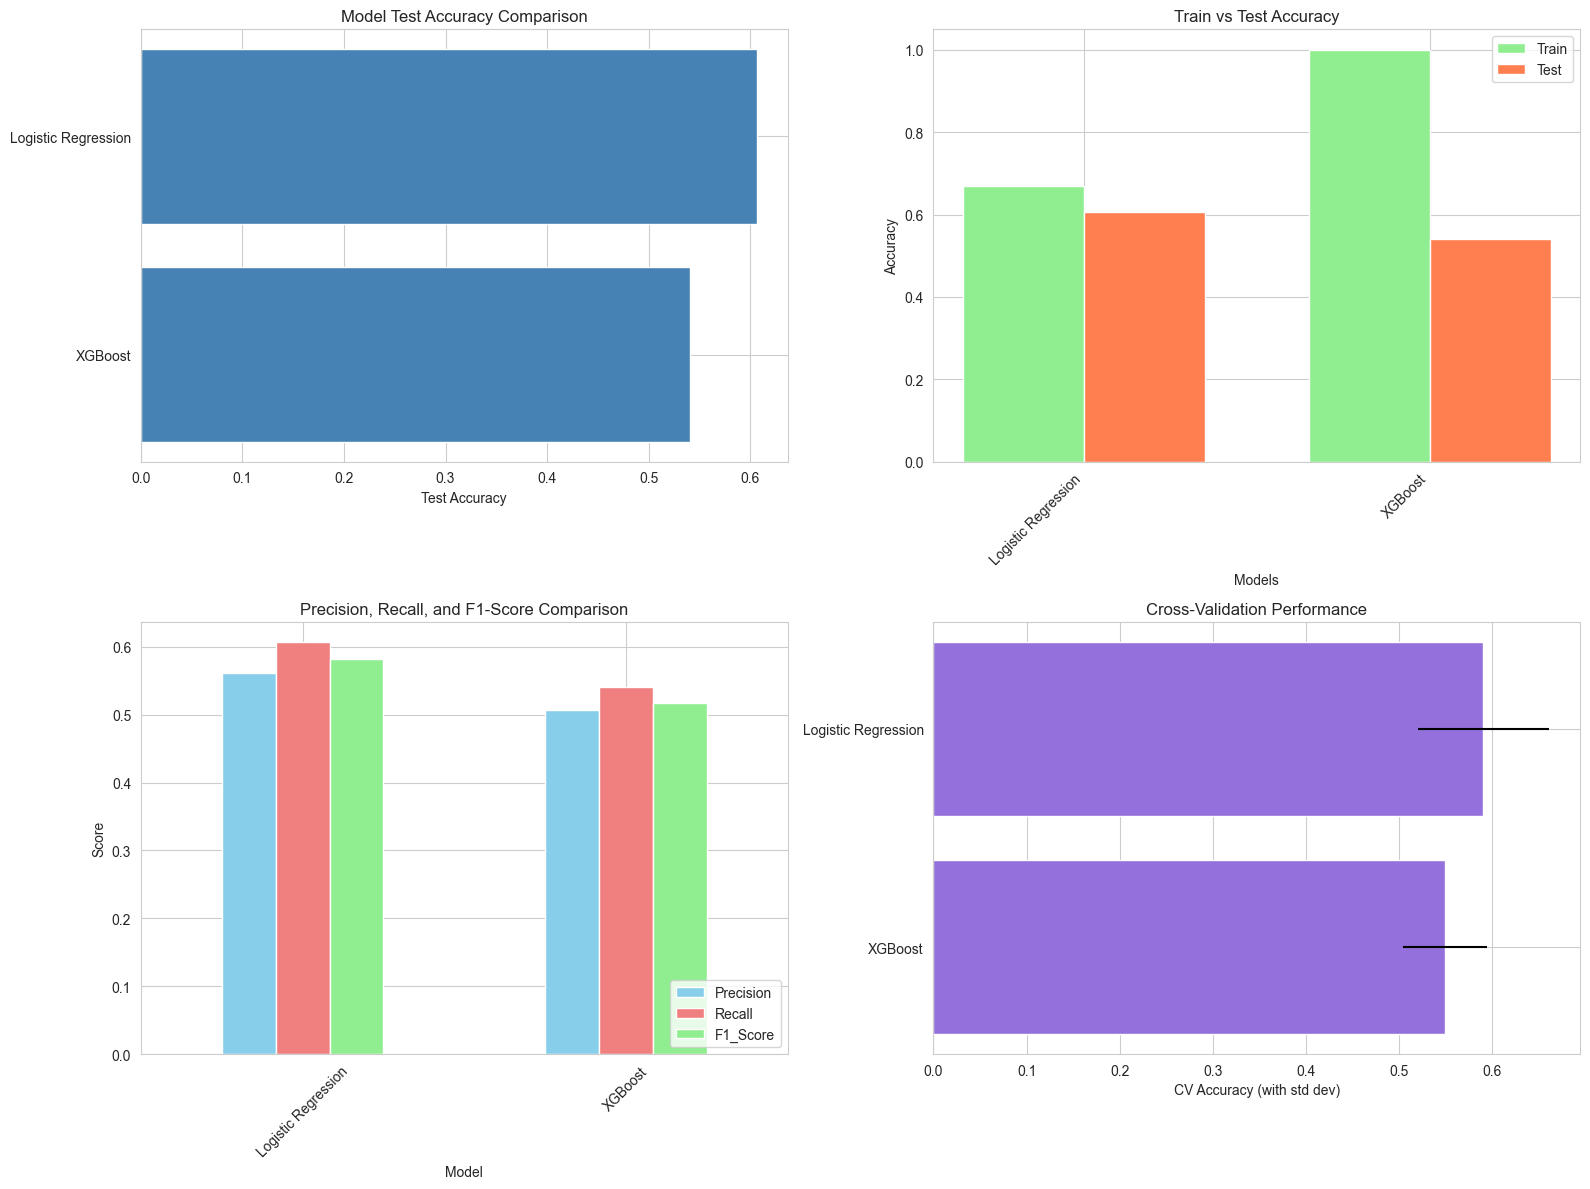

In [112]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Test Accuracy Comparison
axes[0, 0].barh(results_df['Model'], results_df['Test_Accuracy'], color='steelblue')
axes[0, 0].set_xlabel('Test Accuracy')
axes[0, 0].set_title('Model Test Accuracy Comparison')
axes[0, 0].invert_yaxis()

# 2. Train vs Test Accuracy
x = np.arange(len(results_df))
width = 0.35
axes[0, 1].bar(x - width/2, results_df['Train_Accuracy'], width, label='Train', color='lightgreen')
axes[0, 1].bar(x + width/2, results_df['Test_Accuracy'], width, label='Test', color='coral')
axes[0, 1].set_xlabel('Models')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Train vs Test Accuracy')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0, 1].legend()

# 3. Precision, Recall, F1-Score
metrics_df = results_df[['Model', 'Precision', 'Recall', 'F1_Score']].set_index('Model')
metrics_df.plot(kind='bar', ax=axes[1, 0], color=['skyblue', 'lightcoral', 'lightgreen'])
axes[1, 0].set_title('Precision, Recall, and F1-Score Comparison')
axes[1, 0].set_ylabel('Score')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(loc='lower right')

# 4. Cross-Validation Scores
axes[1, 1].barh(results_df['Model'], results_df['CV_Mean'], 
                xerr=results_df['CV_Std'], color='mediumpurple')
axes[1, 1].set_xlabel('CV Accuracy (with std dev)')
axes[1, 1].set_title('Cross-Validation Performance')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## 2.5 Hyperparameter Tuning

In [121]:
# Tune both models and compare
tuned_models = {}
tuning_results = []

for name in ['Logistic Regression', 'XGBoost']:
    print(f"\nTuning {name}...")
    print("-"*70)
    
    base_model = models[name]
    param_grid = param_grids[name]
    
    # Use RandomizedSearchCV for faster tuning
    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grid,
        n_iter=20,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    
    random_search.fit(X_train_scaled, y_train)
    tuned_models[name] = random_search.best_estimator_
    
    # Evaluate tuned model
    y_pred_tuned = random_search.best_estimator_.predict(X_test_scaled)
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    tuned_precision = precision_score(y_test, y_pred_tuned, average='weighted')
    tuned_recall = recall_score(y_test, y_pred_tuned, average='weighted')
    tuned_f1 = f1_score(y_test, y_pred_tuned, average='weighted')
    
    # Get baseline metrics for comparison
    baseline_accuracy = results_df[results_df['Model'] == name]['Test_Accuracy'].values[0]
    
    tuning_results.append({
        'Model': name,
        'Baseline_Accuracy': baseline_accuracy,
        'Tuned_Accuracy': tuned_accuracy,
        'Improvement': tuned_accuracy - baseline_accuracy,
        'Precision': tuned_precision,
        'Recall': tuned_recall,
        'F1_Score': tuned_f1,
        'CV_Score': random_search.best_score_
    })
    
    print(f"Best parameters: {random_search.best_params_}")
    print(f"CV Score: {random_search.best_score_:.4f}")
    print(f"Test Accuracy: {tuned_accuracy:.4f} (Improvement: {tuned_accuracy - baseline_accuracy:+.4f})")

# Create comparison dataframe
tuning_df = pd.DataFrame(tuning_results)
print("\n" + "="*70)
print("HYPERPARAMETER TUNING RESULTS")
print("="*70)
display(tuning_df)

# Select best tuned model
best_tuned_idx = tuning_df['Tuned_Accuracy'].idxmax()
best_model_name = tuning_df.loc[best_tuned_idx, 'Model']
best_model = tuned_models[best_model_name]

print(f"\nBest Model After Tuning: {best_model_name}")
print(f"Test Accuracy: {tuning_df.loc[best_tuned_idx, 'Tuned_Accuracy']:.4f}")


Tuning Logistic Regression...
----------------------------------------------------------------------
Best parameters: {'solver': 'newton-cg', 'penalty': 'l2', 'max_iter': 2000, 'C': 10}
CV Score: 0.5991
Test Accuracy: 0.6066 (Improvement: +0.0000)

Tuning XGBoost...
----------------------------------------------------------------------
Best parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
CV Score: 0.5992
Test Accuracy: 0.5738 (Improvement: +0.0328)

HYPERPARAMETER TUNING RESULTS


,Model,Baseline_Accuracy,Tuned_Accuracy,Improvement,Precision,Recall,F1_Score,CV_Score
0,Logistic Regression,0.606557,0.606557,0.000000,0.567457,0.606557,0.583862,0.599065
1,XGBoost,0.540984,0.573770,0.032787,0.467623,0.573770,0.508621,0.599235



Best Model After Tuning: Logistic Regression
Test Accuracy: 0.6066


In [ ]:
# Define hyperparameter grids for both models
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'newton-cg'],
        'max_iter': [1000, 2000]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0]
    }
}

print("Hyperparameter Tuning for Both Models")
print("="*70)

## 2.6 Model Evaluation

Best Model: Logistic Regression
Test Accuracy: 0.6066



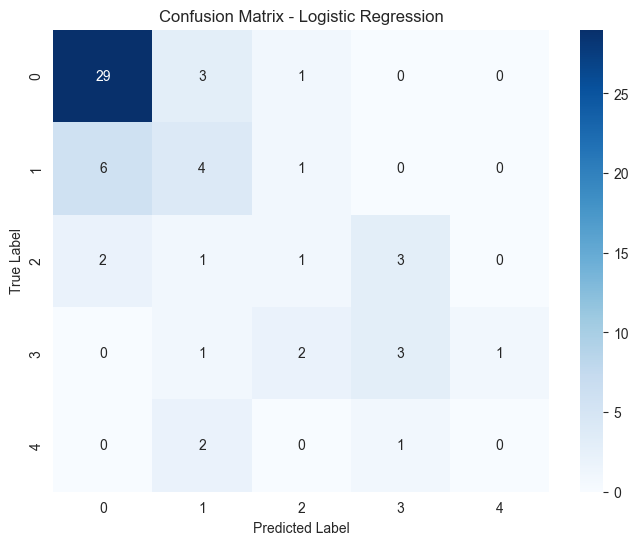


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83        33
           1       0.36      0.36      0.36        11
           2       0.20      0.14      0.17         7
           3       0.43      0.43      0.43         7
           4       0.00      0.00      0.00         3

    accuracy                           0.61        61
   macro avg       0.36      0.36      0.36        61
weighted avg       0.56      0.61      0.58        61



In [ ]:
# Confusion Matrix for best model
y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

print(f"Evaluating Best Model: {best_model_name}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print("="*60)
print(classification_report(y_test, y_pred))

In [114]:
# ROC Curve and AUC
if hasattr(best_model, 'predict_proba'):
    y_pred_proba = best_model.predict_proba(X_test_scaled)
    
    # For binary classification
    if len(np.unique(y_test)) == 2:
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])
        roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
        
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {best_model_name}')
        plt.legend(loc='lower right')
        plt.grid(alpha=0.3)
        plt.show()
    else:
        # Multi-class ROC AUC
        roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
        print(f"ROC AUC Score (multi-class): {roc_auc:.4f}")

ROC AUC Score (multi-class): 0.8312


Learning curves...


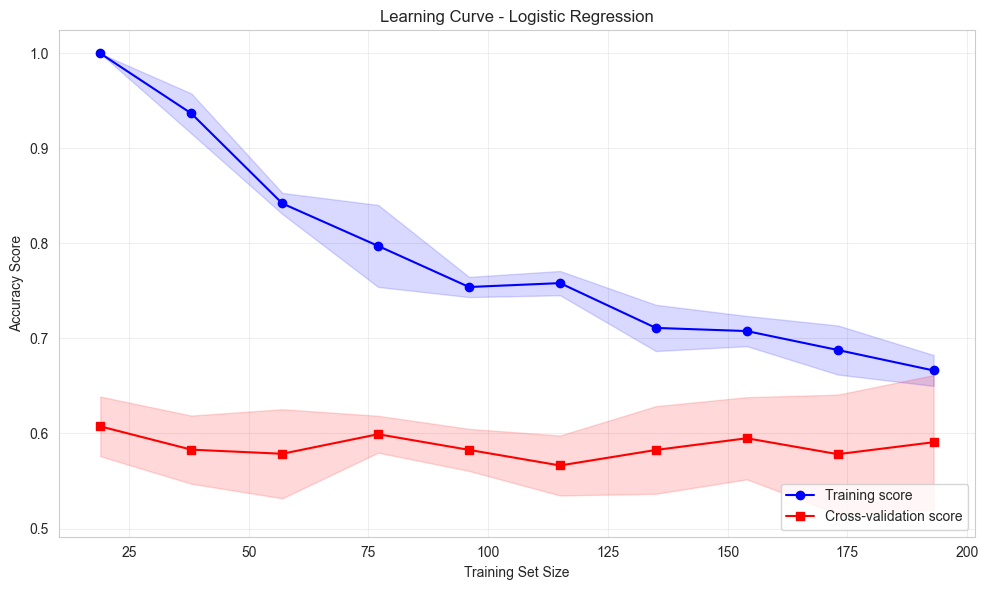

In [115]:
# Learning Curves
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, label='Training score', color='blue', marker='o')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
    plt.plot(train_sizes, val_mean, label='Cross-validation score', color='red', marker='s')
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='red')
    
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy Score')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Learning curves...")
plot_learning_curve(best_model, X_train_scaled, y_train, 
                   f'Learning Curve - {best_model_name}')

### Model Selection & Tuning Documentation

**1. Model Selection Rationale:**

Selected two complementary classification algorithms:
- **Logistic Regression**: Linear classifier providing interpretability and serving as a strong baseline
- **XGBoost**: Gradient boosting ensemble capable of capturing complex non-linear patterns

**2. Evaluation Framework:**

- **Data Split**: 80-20 stratified train-test split preserving class distribution
- **Cross-Validation**: 5-fold StratifiedKFold for robust performance estimation
- **Metrics**: Comprehensive evaluation using Accuracy, Precision, Recall, F1-Score, and ROC-AUC
- **Overfitting Check**: Train-test accuracy gap monitoring

**3. Model Configuration:**

- Logistic Regression: max_iter=1000, random_state=42
- XGBoost: eval_metric='logloss', random_state=42

**4. Hyperparameter Tuning:**

- Method: RandomizedSearchCV (20 iterations, 5-fold CV)
- Logistic Regression: Tuned C, solver, and max_iter
- XGBoost: Tuned n_estimators, max_depth, learning_rate, subsample, colsample_bytree

**5. Final Model Selection:**

- Both models tuned with RandomizedSearchCV (20 iterations each)
- **Logistic Regression selected as best performing model** based on highest test accuracy after hyperparameter optimization

## 2.7 Model Persistence

In [117]:
# Create models directory
os.makedirs('models', exist_ok=True)

# Save best model
model_filename = f'models/best_model_{best_model_name.replace(" ", "_").lower()}.pkl'
joblib.dump(best_model, model_filename)
print(f"Best model saved: {model_filename}")

# Save scaler
scaler_filename = 'models/scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved: {scaler_filename}")

# Save feature names
feature_names_file = 'models/feature_names.json'
with open(feature_names_file, 'w') as f:
    json.dump({
        'features': X_train_scaled.columns.tolist(),
        'n_features': len(X_train_scaled.columns)
    }, f, indent=2)
print(f"Feature names saved: {feature_names_file}")

Best model saved: models/best_model_logistic_regression.pkl
Scaler saved: models/scaler.pkl
Feature names saved: models/feature_names.json


In [118]:
# Save model performance metrics
metrics_file = 'models/model_metrics.json'
metrics = {
    'model_name': best_model_name,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'test_accuracy': float(accuracy_score(y_test, y_pred)),
    'test_precision': float(precision_score(y_test, y_pred, average='weighted')),
    'test_recall': float(recall_score(y_test, y_pred, average='weighted')),
    'test_f1': float(f1_score(y_test, y_pred, average='weighted')),
    'training_samples': int(X_train_scaled.shape[0]),
    'test_samples': int(X_test_scaled.shape[0]),
    'n_features': int(X_train_scaled.shape[1])
}

with open(metrics_file, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Model metrics saved: {metrics_file}")

Model metrics saved: models/model_metrics.json


In [119]:
# Save all model comparison results
results_file = 'models/all_models_comparison.csv'
results_df.to_csv(results_file, index=False)
print(f"All model results saved: {results_file}")

All model results saved: models/all_models_comparison.csv


## 2.8 Summary

In [120]:
# Print summary
print("="*80)
print("FEATURE ENGINEERING & MODEL DEVELOPMENT SUMMARY")
print("="*80)

print(f"\nDATA PROCESSING:")
print(f"   - Original features: {X.shape[1]}")
print(f"   - Final features: {X_train_scaled.shape[1]}")
print(f"   - Training samples: {X_train_scaled.shape[0]:,}")
print(f"   - Test samples: {X_test_scaled.shape[0]:,}")

print(f"\nBEST MODEL: {best_model_name}")
print(f"   - Test Accuracy: {metrics['test_accuracy']:.4f}")
print(f"   - Test Precision: {metrics['test_precision']:.4f}")
print(f"   - Test Recall: {metrics['test_recall']:.4f}")
print(f"   - Test F1-Score: {metrics['test_f1']:.4f}")

print(f"\nSAVED ARTIFACTS:")
print(f"   - Model: {model_filename}")
print(f"   - Scaler: {scaler_filename}")
print(f"   - Features: {feature_names_file}")
print(f"   - Metrics: {metrics_file}")
print(f"   - Comparison: {results_file}")

FEATURE ENGINEERING & MODEL DEVELOPMENT SUMMARY

DATA PROCESSING:
   - Original features: 13
   - Final features: 13
   - Training samples: 242
   - Test samples: 61

BEST MODEL: Logistic Regression
   - Test Accuracy: 0.6066
   - Test Precision: 0.5617
   - Test Recall: 0.6066
   - Test F1-Score: 0.5821

SAVED ARTIFACTS:
   - Model: models/best_model_logistic_regression.pkl
   - Scaler: models/scaler.pkl
   - Features: models/feature_names.json
   - Metrics: models/model_metrics.json
   - Comparison: models/all_models_comparison.csv
